Task 2 — Sentiment & Thematic 

In [1]:
# Imports & setup
import re, string, json
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
tqdm.pandas()

# NLP
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("vader_lexicon")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# transformers (DistilBERT) 
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# gensim  (topic modeling)
try:
    from gensim.corpora.dictionary import Dictionary
    from gensim.models.ldamodel import LdaModel
    HAS_GENSIM = True
except Exception:
    HAS_GENSIM = False

# Visualization 
import matplotlib.pyplot as plt

# Paths
RAW_CSV = Path(r"C:/Users/User/Desktop/KAIM/Week_2/Fintech_Customer_Experience/data/processed/reviews_processed.csv")
OUT_CSV = Path(r"C:/Users/User/Desktop/KAIM/Week_2/Fintech_Customer_Experience/data/processed/task2_reviews_sentiment_theme.csv")
KW_CSV = Path(r"C:/Users/User/Desktop/KAIM/Week_2/Fintech_Customer_Experience/data/processed/task2_top_keywords.csv")


c:\Users\User\anaconda3\envs\fintech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
# Load CSV robustly 
df = pd.read_csv(RAW_CSV, sep=",", engine="python", on_bad_lines="skip", encoding="utf-8")
print("Rows loaded:", len(df))
df.columns


Rows loaded: 942


Index(['review_id', 'review_text', 'rating', 'review_date', 'review_year',
       'review_month', 'bank_code', 'bank_name', 'user_name', 'thumbs_up',
       'text_length', 'source'],
      dtype='object')

In [4]:
# Basic structural cleaning 
df.columns = [c.strip() for c in df.columns]
# Ensure expected columns exist
expected = {"review_id","review_text","rating","review_date","bank_name"}
missing = expected - set(df.columns)
if missing:
    print("Warning: missing columns:", missing)
# Make sure review_text is str
df["review_text"] = df["review_text"].astype(str)


In [7]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")   
nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [8]:
# Create cleaned text for TF-IDF/themes (remove Amharic/Ethiopic tokens)
STOPWORDS = set(stopwords.words("english"))
# add bank names to stopwords to avoid dominance
extra_sw = { "bank", "app", "cbe", "boa", "dashen", "bankofabyssinia", "commercial" }
STOPWORDS.update(extra_sw)

LEMMATIZER = WordNetLemmatizer()
AMHARIC_RE = re.compile(r'[\u1200-\u137F]+')   # Ethiopic script tokens
EMOJI_RE = re.compile("[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]+" , flags=re.UNICODE)

def clean_for_keywords(text):
    s = str(text).lower()
    s = re.sub(r"http\S+|www\S+|https\S+", " ", s)
    s = EMOJI_RE.sub(" ", s)
    s = re.sub(r"\d+", " ", s)
    s = s.translate(str.maketrans("", "", string.punctuation))
    tokens = nltk.word_tokenize(s)
    out = []
    for t in tokens:
        if AMHARIC_RE.search(t):            # drop Ethiopic tokens
            continue
        if t in STOPWORDS:
            continue
        if not re.match(r"^[a-zA-Z'\-]+$", t):  # keep latin tokens only
            continue
        out.append(LEMMATIZER.lemmatize(t))
    return out

tqdm.pandas(desc="Cleaning text -> tokens")
df["tokens_clean"] = df["review_text"].progress_apply(clean_for_keywords)
df["clean_text"] = df["tokens_clean"].apply(lambda toks: " ".join(toks))
df["clean_len"] = df["tokens_clean"].apply(len)


Cleaning text -> tokens: 100%|██████████| 942/942 [00:03<00:00, 242.39it/s]


In [22]:
##### Textblob
from textblob import TextBlob

df["tb_polarity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df["tb_subjectivity"] = df["review_text"].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)


In [9]:
#  VADER sentiment (fast lexicon) 
sia = SentimentIntensityAnalyzer()

def vader_compound(text):
    try:
        return sia.polarity_scores(str(text))["compound"]
    except Exception:
        return 0.0

def vader_label(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

tqdm.pandas(desc="VADER scoring")
df["vader_compound"] = df["review_text"].progress_apply(vader_compound)
df["vader_sentiment"] = df["vader_compound"].apply(vader_label)


VADER scoring: 100%|██████████| 942/942 [00:00<00:00, 3121.48it/s]


In [10]:
# DistilBERT sentiment. Batched inference with neutral threshold.
MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

def predict_distilbert(texts, batch_size=64, neutrality_threshold=0.60):
    labels = []
    scores = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt")
        enc = {k: v.to(device) for k,v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1).cpu().numpy()  # shape (B,2)
        for p in probs:
            neg_p, pos_p = float(p[0]), float(p[1])
            max_p = max(neg_p, pos_p)
            if max_p < neutrality_threshold:
                labels.append("neutral")
                scores.append(max_p)
            else:
                labels.append("positive" if pos_p>neg_p else "negative")
                scores.append(max_p)
    return labels, scores

# Run on raw reviews (keeps original text)
texts = df["review_text"].fillna("").tolist()
print("Running DistilBERT inference (this may take time)...")
labels, scores = predict_distilbert(texts, batch_size=64, neutrality_threshold=0.60)
df["distilbert_label"] = labels
df["distilbert_score"] = scores


c:\Users\User\anaconda3\envs\fintech\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Running DistilBERT inference (this may take time)...


In [12]:
# TF-IDF keyword extraction (1-2 grams)
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=2000, min_df=3)
corpus = df["clean_text"].fillna("").astype(str).tolist()
tfidf_matrix = tfidf.fit_transform(corpus)
feature_names = np.array(tfidf.get_feature_names_out())

# function to get top terms for indices
def top_terms_for_indices(idxs, top_n=25):
    if len(idxs)==0:
        return []
    sub = tfidf_matrix[idxs,:]
    scores = np.asarray(sub.sum(axis=0)).ravel()
    top_idx = np.argsort(scores)[-top_n:][::-1]
    return list(zip(feature_names[top_idx], scores[top_idx]))

# per-bank top keywords
bank_keywords = {}
for bank in df["bank_name"].unique():
    idxs = df.index[df["bank_name"]==bank].tolist()
    bank_keywords[bank] = top_terms_for_indices(idxs, top_n=40)

# Save keywords file
kw_rows=[]
for bank, pairs in bank_keywords.items():
    for term,score in pairs:
        kw_rows.append({"bank":bank,"term":term,"tfidf":float(score)})
pd.DataFrame(kw_rows).to_csv(KW_CSV, index=False)
print("Saved top keywords to", KW_CSV)


Saved top keywords to C:\Users\User\Desktop\KAIM\Week_2\Fintech_Customer_Experience\data\processed\task2_top_keywords.csv


In [13]:
# Rule-based theme mapping (adjust keywords after inspecting TF-IDF)
THEME_KEYWORDS = {
    "Account Access": ["login","password","otp","pin","signin","sign in","signup","locked","session","authenticate","authentication"],
    "Transaction Performance": ["slow","loading","lag","timeout","transfer slow","transfer","processing","failed transfer","processing time"],
    "Crashes & Bugs": ["crash","crashes","bug","error","fail","failed","stuck","exception"],
    "UI / UX": ["ui","user interface","interface","navigation","design","button","screen","layout","user friendly"],
    "Customer Support": ["support","service","help","customer","response","call","email","support team"],
    "Feature Requests": ["fingerprint","biometric","dark mode","feature","update","add","missing","balance alert"],
    "Security & Fraud": ["secure","security","fraud","unauthorized","phishing","scam"],
    "Payments & Cards": ["card","atm","withdraw","payment","pos","card blocked"]
}

# flatten mapping
kw_to_theme = {}
for theme,kws in THEME_KEYWORDS.items():
    for kw in kws:
        kw_to_theme[kw] = theme

def identify_themes(clean_text):
    found=set()
    if not isinstance(clean_text,str) or len(clean_text.strip())==0:
        return []
    txt = " " + clean_text + " "
    for kw,theme in kw_to_theme.items():
        if kw in txt:
            found.add(theme)
    return sorted(found)

df["themes"] = df["clean_text"].progress_apply(identify_themes)
df["themes_str"] = df["themes"].apply(lambda x: ", ".join(x) if x else "Other")


VADER scoring: 100%|██████████| 942/942 [00:00<00:00, 58195.02it/s]


In [14]:
#  LDA (topic modeling) for exploration - only if gensim available and tokens exist
if HAS_GENSIM and "tokens_clean" in df.columns:
    dictionary = Dictionary(df["tokens_clean"])
    corpus = [dictionary.doc2bow(toks) for toks in df["tokens_clean"]]
    lda = LdaModel(corpus=corpus, id2word=dictionary, num_topics=6, passes=10, random_state=42)
    topics = lda.show_topics(num_topics=6, num_words=10, formatted=False)
    for idx, topic in topics:
        print(f"\n--- Topic {idx+1} ---")
        for word,weight in topic:
            print(f"{word:15s} weight={weight:.4f}")
else:
    print("Gensim not available or tokens missing; skipping LDA.")



--- Topic 1 ---
nice            weight=0.0297
cant            weight=0.0137
money           weight=0.0128
wow             weight=0.0107
time            weight=0.0104
even            weight=0.0097
doesnt          weight=0.0096
transaction     weight=0.0091
problem         weight=0.0087
love            weight=0.0076

--- Topic 2 ---
best            weight=0.0895
use             weight=0.0198
friendly        weight=0.0135
cant            weight=0.0110
banking         weight=0.0109
easy            weight=0.0105
ethiopia        weight=0.0103
account         weight=0.0101
user            weight=0.0098
ever            weight=0.0090

--- Topic 3 ---
banking         weight=0.0226
work            weight=0.0202
great           weight=0.0167
amazing         weight=0.0139
mobile          weight=0.0134
easy            weight=0.0128
use             weight=0.0114
one             weight=0.0102
update          weight=0.0100
time            weight=0.0100

--- Topic 4 ---
good            weight=0.0845
fa

In [15]:
#  Aggregations 
# Sentiment coverage
sent_coverage = df["distilbert_label"].notna().mean()
print(f"DistilBERT coverage: {sent_coverage:.2%}")

# Mean sentiment by bank & rating (convert labels to numeric for mean: pos=1, neu=0, neg=-1)
map_num = {"positive":1, "neutral":0, "negative":-1}
df["distilbert_num"] = df["distilbert_label"].map(map_num)

agg = df.groupby(["bank_name","rating"])["distilbert_num"].agg(["count","mean"]).reset_index()
agg.head(20)


DistilBERT coverage: 100.00%


,bank_name,rating,count,mean
0,Bank of Abyssinia (BOA),1,123,-0.869919
1,Bank of Abyssinia (BOA),2,13,-0.769231
2,Bank of Abyssinia (BOA),3,19,-0.368421
3,Bank of Abyssinia (BOA),4,17,-0.294118
4,Bank of Abyssinia (BOA),5,152,0.559211
5,Commercial Bank of Ethiopia,1,48,-0.583333
6,Commercial Bank of Ethiopia,2,11,-0.636364
7,Commercial Bank of Ethiopia,3,19,-0.473684
8,Commercial Bank of Ethiopia,4,31,0.032258
9,Commercial Bank of Ethiopia,5,191,0.570681


In [16]:
# Top themes per bank
def top_themes(bank, top_n=10):
    sub = df[df["bank_name"]==bank]
    allthemes = sum(sub["themes"].apply(lambda x: x if isinstance(x,list) else []).tolist(), [])
    return Counter(allthemes).most_common(top_n)

for bank in df["bank_name"].unique():
    print("\n===", bank, "===")
    print(top_themes(bank, top_n=8))



=== Bank of Abyssinia (BOA) ===
[('Transaction Performance', 33), ('Customer Support', 25), ('Feature Requests', 25), ('Crashes & Bugs', 24), ('Account Access', 17), ('UI / UX', 10), ('Payments & Cards', 8), ('Security & Fraud', 5)]

=== Commercial Bank of Ethiopia ===
[('Feature Requests', 29), ('Customer Support', 19), ('Transaction Performance', 15), ('UI / UX', 13), ('Account Access', 8), ('Payments & Cards', 8), ('Crashes & Bugs', 6), ('Security & Fraud', 4)]

=== Dashen Bank ===
[('UI / UX', 32), ('Feature Requests', 30), ('Transaction Performance', 27), ('Customer Support', 25), ('Crashes & Bugs', 16), ('Payments & Cards', 14), ('Security & Fraud', 11), ('Account Access', 8)]


In [17]:
# Save results 
OUT_CSV = Path(r"C:/Users/User/Desktop/KAIM/Week_2/Fintech_Customer_Experience/data/processed/task2_reviews_sentiment_theme.csv")
cols_out = [
 "review_id","review_text","clean_text","tokens_clean","rating","review_date","bank_name",
 "vader_compound","vader_sentiment","distilbert_label","distilbert_score","distilbert_num",
 "themes_str"
]
df[cols_out].to_csv(OUT_CSV, index=False, encoding="utf-8")
print("Saved Task2 output to:", OUT_CSV)


Saved Task2 output to: C:\Users\User\Desktop\KAIM\Week_2\Fintech_Customer_Experience\data\processed\task2_reviews_sentiment_theme.csv


Compute TextBlob sentiment

In [23]:
from textblob import TextBlob

def tb_sentiment(text):
    tb = TextBlob(str(text))
    polarity = tb.sentiment.polarity
    if polarity >= 0.05:
        label = "positive"
    elif polarity <= -0.05:
        label = "negative"
    else:
        label = "neutral"
    return polarity, label

# Apply to dataframe
tqdm.pandas(desc="TextBlob scoring")
df[["tb_polarity", "tb_sentiment"]] = df["review_text"].progress_apply(
    lambda x: pd.Series(tb_sentiment(x))
)


TextBlob scoring: 100%|██████████| 942/942 [00:00<00:00, 1001.16it/s]


VADER sentiment

In [24]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def vader_compound(text):
    return sia.polarity_scores(str(text))["compound"]

def vader_label(c):
    if c >= 0.05:
        return "positive"
    elif c <= -0.05:
        return "negative"
    else:
        return "neutral"

df["vader_compound"] = df["review_text"].progress_apply(vader_compound)
df["vader_sentiment"] = df["vader_compound"].apply(vader_label)


TextBlob scoring: 100%|██████████| 942/942 [00:00<00:00, 4079.07it/s]


DistilBERT sentiment

In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def distilbert_sentiment(texts, batch_size=32, neutral_thresh=0.05):
    all_labels, all_probs = [], []
    for i in tqdm(range(0, len(texts), batch_size), desc="DistilBERT inference"):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**encodings)
            probs = torch.softmax(outputs.logits, dim=1).numpy()
        for prob in probs:
            pos_prob = prob[1]
            if abs(pos_prob - 0.5) < neutral_thresh:
                label = "neutral"
            elif pos_prob >= 0.5:
                label = "positive"
            else:
                label = "negative"
            all_labels.append(label)
            all_probs.append(pos_prob)
    return all_labels, all_probs

texts = df["review_text"].astype(str).tolist()
labels, probs = distilbert_sentiment(texts)
df["distilbert_sentiment"] = labels
df["distilbert_pos_prob"] = probs


DistilBERT inference: 100%|██████████| 30/30 [00:53<00:00,  1.80s/it]


Compare all 3 methods

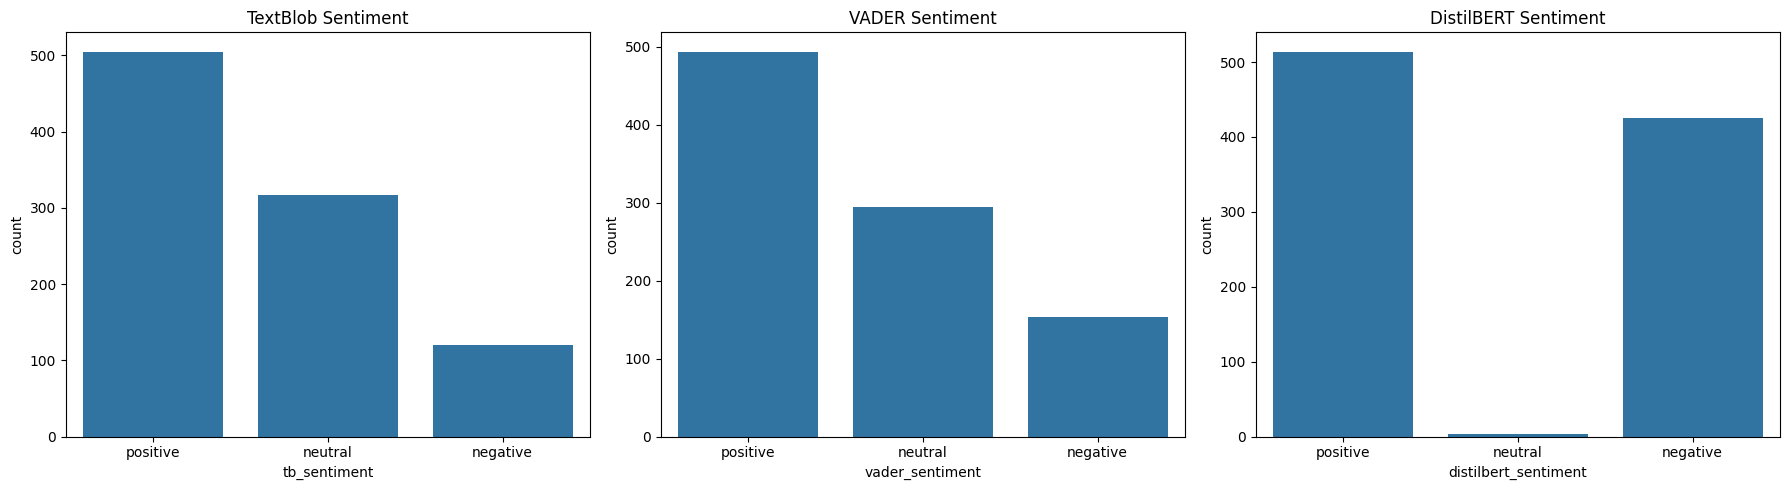

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x="tb_sentiment", data=df, ax=axes[0], order=["positive", "neutral", "negative"])
axes[0].set_title("TextBlob Sentiment")

sns.countplot(x="vader_sentiment", data=df, ax=axes[1], order=["positive", "neutral", "negative"])
axes[1].set_title("VADER Sentiment")

sns.countplot(x="distilbert_sentiment", data=df, ax=axes[2], order=["positive", "neutral", "negative"])
axes[2].set_title("DistilBERT Sentiment")

plt.tight_layout()
plt.show()


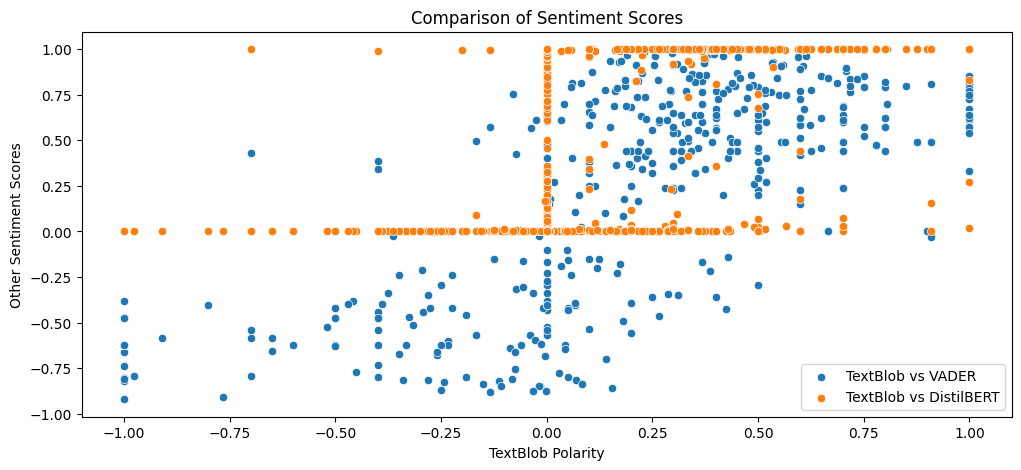

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.scatterplot(x="tb_polarity", y="vader_compound", data=df, label="TextBlob vs VADER")
sns.scatterplot(x="tb_polarity", y="distilbert_pos_prob", data=df, label="TextBlob vs DistilBERT")

plt.xlabel("TextBlob Polarity")
plt.ylabel("Other Sentiment Scores")
plt.title("Comparison of Sentiment Scores")
plt.legend()
plt.show()
